## Customer Shopping Behavior Analysis

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("customer_shopping_behavior.csv")


In [3]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [4]:
print(df.isnull().sum())

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64


### Dataset contains 3900 rows and 18 columns. Missing values were found in the "Review Rating" column and were handled using mean imputation.

In [9]:
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())

In [10]:
print(df.isnull().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


#### null value filled

In [5]:
total_sales = df['Purchase Amount (USD)'].sum()
print("Total Sales:", total_sales)

Total Sales: 233081


### Total sales generated is 233081 USD.

In [6]:
print(df['Age'].mean())

44.06846153846154


In [7]:
df.groupby('Gender')['Purchase Amount (USD)'].sum()

Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64

###  -Male customers contribute more to total sales.

In [8]:
df.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

### The highest sales are generated from Clothing category.

In [9]:
df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

Location
Montana           5784
Illinois          5617
California        5605
Idaho             5587
Nevada            5514
Alabama           5261
New York          5257
North Dakota      5220
West Virginia     5174
Nebraska          5172
New Mexico        5014
Minnesota         4977
Pennsylvania      4926
Mississippi       4883
Alaska            4867
Vermont           4860
Louisiana         4848
Virginia          4842
Arkansas          4828
Maryland          4795
Tennessee         4772
Delaware          4758
North Carolina    4742
Texas             4712
Missouri          4691
Indiana           4655
Ohio              4649
Georgia           4645
Washington        4623
Michigan          4533
Utah              4443
South Carolina    4439
Kentucky          4402
Maine             4388
Massachusetts     4384
Oklahoma          4376
Arizona           4326
Wyoming           4309
Oregon            4243
South Dakota      4236
Connecticut       4226
Colorado          4222
New Hampshire     4219
Io

 ### The top location contributing to sales is Montana

In [10]:
df.groupby('Discount Applied')['Purchase Amount (USD)'].mean()

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

### Customers with discounts tend to spend less.

In [12]:
df.groupby('Season')['Purchase Amount (USD)'].sum()

Season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: Purchase Amount (USD), dtype: int64

### Sales are highest in Fall season.

In [14]:
df['Review Rating'].mean()

np.float64(3.750064716541548)

### Average rating is 3.75

In [15]:
df.groupby('Previous Purchases')['Purchase Amount (USD)'].mean()

Previous Purchases
1     58.469880
2     60.333333
3     58.560440
4     61.274725
5     64.252874
6     55.850575
7     61.200000
8     66.671642
9     63.784615
10    58.184211
11    59.500000
12    59.253165
13    55.884058
14    57.967391
15    55.863014
16    62.157143
17    61.462687
18    59.142857
19    57.474359
20    61.891566
21    57.979167
22    54.753846
23    57.904110
24    60.197802
25    61.278481
26    58.870130
27    57.756410
28    61.887500
29    59.739130
30    59.353659
31    57.288660
32    61.530864
33    61.987805
34    54.050633
35    59.269841
36    62.239437
37    60.512821
38    65.142857
39    57.061728
40    54.207317
41    60.757143
42    58.855422
43    61.687500
44    61.291667
45    57.566265
46    59.589744
47    62.655556
48    63.588889
49    56.500000
50    65.272727
Name: Purchase Amount (USD), dtype: float64

#### Customers with more previous purchases tend to spend more.

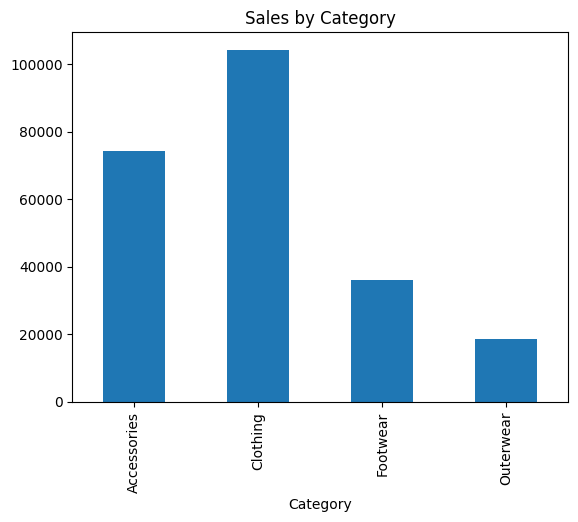

In [20]:
import matplotlib.pyplot as plt

df.groupby('Category')['Purchase Amount (USD)'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

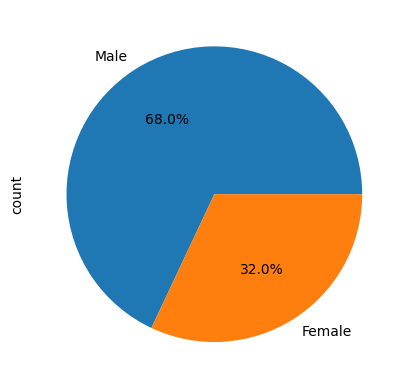

In [21]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.show()

In [24]:
df['Spending Level'] = pd.cut(df['Purchase Amount (USD)'],
                             bins=[0, 50, 150, 500],
                             labels=['Low', 'Medium', 'High'])

print(df['Spending Level'].value_counts())

Spending Level
Medium    2386
Low       1514
High         0
Name: count, dtype: int64


### Customers were segmented into Low, Medium, and High spenders based on purchase amount.

In [25]:
df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False).head(10)

Item Purchased
Blouse        10410
Shirt         10332
Dress         10320
Pants         10090
Jewelry       10010
Sunglasses     9649
Belt           9635
Scarf          9561
Sweater        9462
Shorts         9433
Name: Purchase Amount (USD), dtype: int64

### Top 10 most purchased products were identified.

In [26]:
df['Age Group'] = pd.cut(df['Age'],
                        bins=[18,25,35,50,70],
                        labels=['18-25','26-35','36-50','50+'])

df.groupby('Age Group')['Purchase Amount (USD)'].mean()

C:\Users\mahesh\AppData\Local\Temp\ipykernel_26040\1075547398.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age Group')['Purchase Amount (USD)'].mean()


Age Group
18-25    60.739044
26-35    59.760108
36-50    59.072007
50+      59.945799
Name: Purchase Amount (USD), dtype: float64

### The age group 18 - 25 spends the most on shopping.

In [27]:
df.groupby('Previous Purchases')['Purchase Amount (USD)'].sum()

Previous Purchases
1     4853
2     4344
3     5329
4     5576
5     5590
6     4859
7     3978
8     4467
9     4146
10    4422
11    4879
12    4681
13    3856
14    5333
15    4078
16    4351
17    4118
18    4968
19    4483
20    5137
21    5566
22    3559
23    4227
24    5478
25    4841
26    4533
27    4505
28    4951
29    4122
30    4867
31    5557
32    4984
33    5083
34    4270
35    3734
36    4419
37    4720
38    4560
39    4622
40    4445
41    4253
42    4885
43    3948
44    4413
45    4778
46    4648
47    5639
48    5723
49    3277
50    5026
Name: Purchase Amount (USD), dtype: int64

### Repeat customers contribute more revenue compared to new customers.

In [28]:
df.groupby('Payment Method')['Purchase Amount (USD)'].sum()

Payment Method
Bank Transfer    36544
Cash             40002
Credit Card      40310
Debit Card       38742
PayPal           40109
Venmo            37374
Name: Purchase Amount (USD), dtype: int64

### Most customer prefer bakk transfer pyment method

In [29]:
df.groupby('Subscription Status')['Purchase Amount (USD)'].mean()

Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64

### Subscribed customers spend less than non-subscribed customers.

In [30]:
df['Frequency of Purchases'].value_counts()

Frequency of Purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

### Most customers purchase on a 3 month basis.

In [31]:
df.corr(numeric_only=True)

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
Customer ID,1.000000,-0.004079,0.011048,0.000247,-0.039159
Age,-0.004079,1.000000,-0.010424,-0.024384,0.040445
Purchase Amount (USD),0.011048,-0.010424,1.000000,0.029859,0.008063
Review Rating,0.000247,-0.024384,0.029859,1.000000,0.003583
Previous Purchases,-0.039159,0.040445,0.008063,0.003583,1.000000


### Correlation analysis shows relationships between age, purchase amount, and previous purchases.

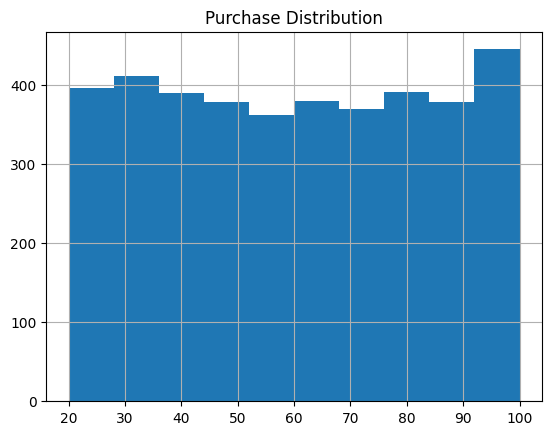

In [32]:
df['Purchase Amount (USD)'].hist()
plt.title("Purchase Distribution")
plt.show()

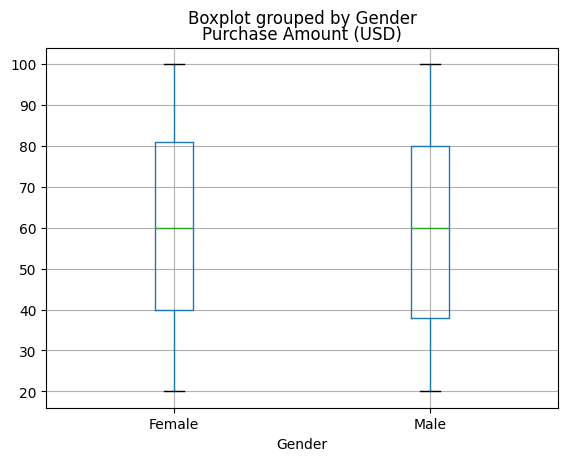

In [33]:
df.boxplot(column='Purchase Amount (USD)', by='Gender')
plt.show()

In [34]:
rfm = df.groupby('Customer ID').agg({
    'Purchase Amount (USD)': 'sum',
    'Previous Purchases': 'count'
}).rename(columns={
    'Purchase Amount (USD)': 'Monetary',
    'Previous Purchases': 'Frequency'
})

print(rfm.head())

             Monetary  Frequency
Customer ID                     
1                  53          1
2                  64          1
3                  73          1
4                  90          1
5                  49          1


In [37]:
df.to_excel("clean_data.xlsx", index=False)

In [38]:
import os
print(os.getcwd())

C:\Users\mahesh\vaidyanth college project 2
